## Codigo para benchmark con random forest

In [ ]:
import os
import io
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit


# --- FIJAR SEMILLAS PARA REPRODUCIBILIDAD EN PYTORCH ---
SEED = 37

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

plt.ion()

In [21]:
# datos tomados del train
ELO_MIN = 1000 
ELO_MAX = 3390
ELO_MEAN = 2028.3
ELO_STD = 593.4
ELO_MEDIAN = 2028.0
ELO_Q1 = 1514.0
ELO_Q3 = 2538.0 
ELO_IQR = ELO_Q3 - ELO_Q1

In [22]:
def cargar_datos_sklearn(ruta_npz,plies_a_usar):
    # Cargar el archivo .npz directamente a la memoria
    datos = np.load(ruta_npz)
    # Extraer arrays (reemplaza 'X' e 'y' por los nombres reales de tus claves si son distintos)
    X = datos['X']
    plies_guardados = datos['plies_guardados'].tolist()
    indices = [plies_guardados.index(p) for p in plies_a_usar]
    X = X[:, indices, :]
    y = datos['y_raw']
    
    # Aplanar las dimensiones del bitboard para scikit-learn
    # Pasa de (N_muestras, 13, 8, 8) o (N_muestras, 13, 64) a (N_muestras, 832)
    X = X.reshape(X.shape[0], -1)
    
    # Forzar el tipo de dato más pequeño posible para los features (bitboards usan 0 y 1)
    # Esto reduce el consumo de RAM en un 75% comparado con float32
    X = X.astype(np.int8)
    return X, y

In [23]:
ply = [21]
X_train, y_train = cargar_datos_sklearn("../data/generado/only_enc/train_51.npz",ply)
X_test, y_test = cargar_datos_sklearn("../data/generado/only_enc/test_51.npz",ply)

In [27]:
indices_muestra = np.random.choice(X_train.shape[0], size=int(X_train.shape[0] * 0.2), replace=False)
X_train_muestra = X_train[indices_muestra]
y_train_muestra = y_train[indices_muestra]

In [28]:
rf = RandomForestRegressor(random_state=42)

param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20], # Límite estricto para evitar crecimiento infinito de árboles
    'min_samples_split': [10, 20, 50]
}

# Configuración segura para la memoria:
# n_jobs=2 limita la clonación del dataset a 2 núcleos.
# pre_dispatch=1 evita que scikit-learn encole trabajos masivos en la memoria RAM.
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=2, 
    pre_dispatch=1, 
    random_state=42,
    verbose=2
)

In [ ]:
random_search.fit(X_train_muestra, y_train_muestra)
mejor_rf = random_search.best_estimator_
print(mejor_rf)
#RandomForestRegressor(max_depth=20, min_samples_split=20, n_estimators=50,random_state=42)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
RandomForestRegressor(max_depth=20, min_samples_split=20, n_estimators=50,
                      random_state=42)


In [30]:
modelo_final = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_split=20,
    random_state=42,
    n_jobs=2  # Fundamental mantenerlo acotado para proteger la RAM
)

# 2. Entrenar el modelo final con todo el dataset de entrenamiento
print("Entrenando el modelo final...")
modelo_final.fit(X_train, y_train)

# 3. Generar las predicciones sobre el conjunto de test
print("Realizando predicciones...")
y_pred = modelo_final.predict(X_test)



Entrenando el modelo final...
Realizando predicciones...


NameError: name 'mean_absolute_error' is not defined

In [31]:
errores_absolutos = np.abs(y_test - y_pred)
errores_cuadraticos = (y_test - y_pred) ** 2
mae = np.mean(errores_absolutos)
mse = np.mean(errores_cuadraticos)
rmse = np.sqrt(mse)
error_mediano = np.median(errores_absolutos)
max_error = np.max(errores_absolutos)

print(f"MAE (Error Absoluto Medio):   {mae:.1f} puntos de Elo")
print(f"Mediana del Error:            {error_mediano:.1f} puntos de Elo")
print(f"RMSE (Raíz Error Cuadrático): {rmse:.1f} puntos de Elo")
print(f"Peor equivocación del modelo: {max_error:.1f} puntos de Elo")


MAE (Error Absoluto Medio):   375.0 puntos de Elo
Mediana del Error:            331.5 puntos de Elo
RMSE (Raíz Error Cuadrático): 459.3 puntos de Elo
Peor equivocación del modelo: 1707.4 puntos de Elo


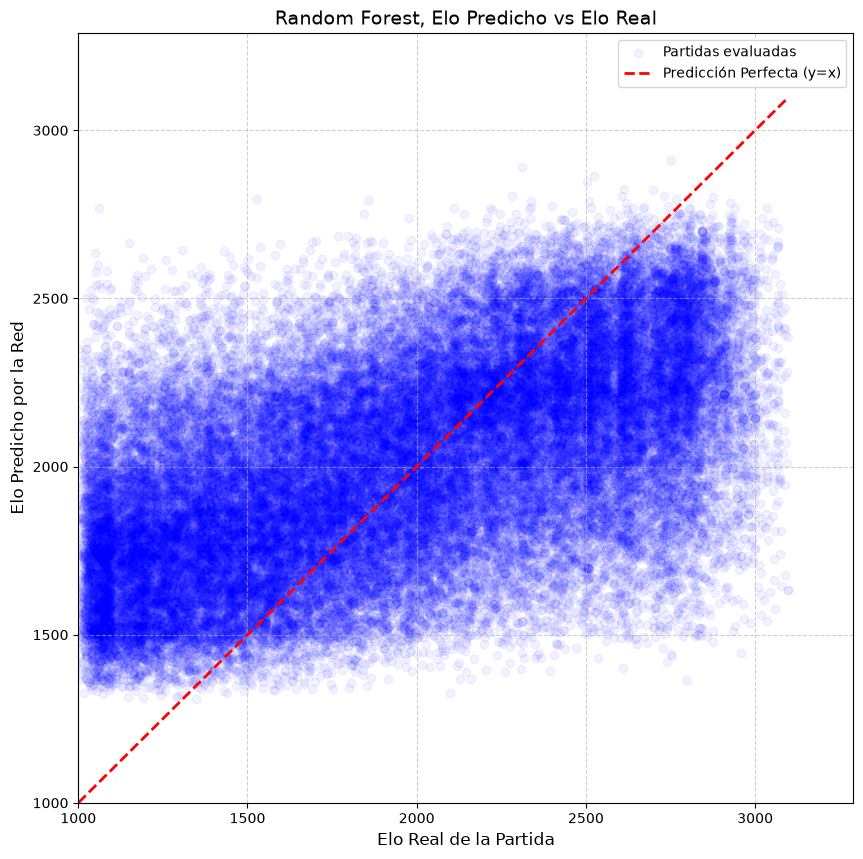

In [32]:
plt.figure(figsize=(10, 10))

plt.scatter(y_test, y_pred, alpha=0.05, color='blue', label='Partidas evaluadas')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.title(f'Random Forest, Elo Predicho vs Elo Real', fontsize=14)
plt.xlabel('Elo Real de la Partida', fontsize=12)
plt.ylabel('Elo Predicho por la Red', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Limitar los ejes a valores lógicos del ajedrez (ej. 800 a 3000)
plt.xlim(ELO_MIN, ELO_MAX-100)
plt.ylim(ELO_MIN, ELO_MAX-100)

plt.show()

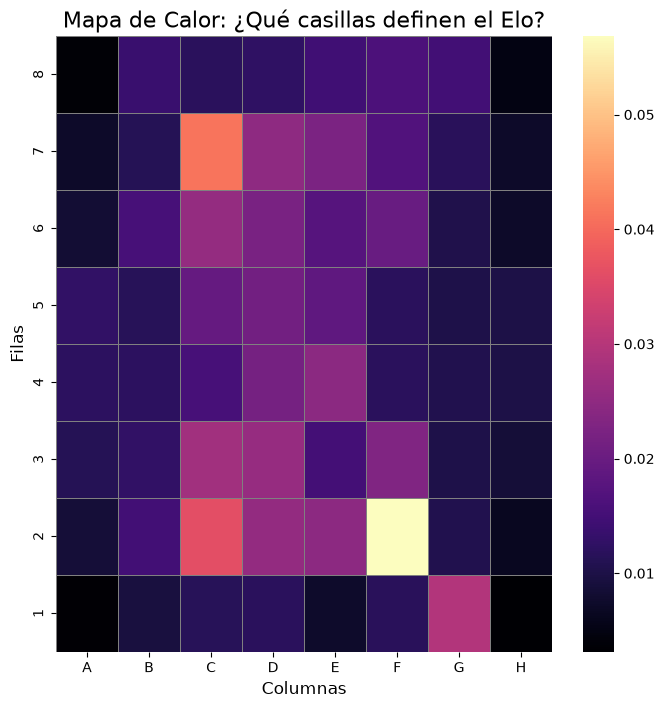

In [ ]:


# 1. Extraer las importancias del Random Forest (array de 832)
importancias_planas = modelo_final.feature_importances_

# 2. Reconstruir la forma matricial original (13 canales, 8 filas, 8 columnas)
importancias_matriz = importancias_planas.reshape(13, 8, 8)

# 3. Sumar la importancia a través de los 13 canales
# Esto nos dice qué "casilla" es importante, sin importar qué pieza esté ahí
importancia_por_casilla = importancias_matriz.sum(axis=0)

# 4. Dibujar el Mapa de Calor
plt.figure(figsize=(8, 8))

# Usamos seaborn para un mapa de calor elegante
# Nota: Dependiendo de cómo armaste tu tablero, puede que necesites invertir el eje Y
sns.heatmap(importancia_por_casilla, 
            cmap='magma',          # Colores de frío (oscuro) a calor (brillante)
            annot=False,           # Pon True si quieres ver los valores numéricos exactos
            xticklabels=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
            yticklabels=['8', '7', '6', '5', '4', '3', '2', '1'],
            linewidths=0.5, 
            linecolor='gray')

plt.title('Mapa de Calor: ¿Qué casillas definen el Elo?', fontsize=16)
plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Filas', fontsize=12)
plt.show()